In [1]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")
print("FastF1 version:", fastf1.__version__)

Libraries imported successfully!
FastF1 version: 3.8.3


In [2]:
# ============================================================
# ENABLE FASTF1 CACHE
# ============================================================

fastf1.Cache.enable_cache("../cache")

print("FastF1 cache enabled.")

FastF1 cache enabled.


In [3]:
# ============================================================
# LOAD 2026 AUSTRALIAN GP RACE
# ============================================================

print("Loading 2026 Australian Grand Prix Race...")

race = fastf1.get_session(
    2026,
    "Australia",
    "R"
)

race.load(
    telemetry=False,
    laps=True,
    weather=False,
    messages=False
)

print("\nRace loaded successfully!")

print("\nEvent:")
print(race.event)

print("\nSession:")
print(race.name)

Loading 2026 Australian Grand Prix Race...


core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No


Race loaded successfully!

Event:
RoundNumber                                                          1
Country                                                      Australia
Location                                                     Melbourne
OfficialEventName    FORMULA 1 QATAR AIRWAYS AUSTRALIAN GRAND PRIX ...
EventDate                                          2026-03-08 00:00:00
EventName                                        Australian Grand Prix
EventFormat                                               conventional
Session1                                                    Practice 1
Session1Date                                 2026-03-06 12:30:00+11:00
Session1DateUtc                                    2026-03-06 01:30:00
Session2                                                    Practice 2
Session2Date                                 2026-03-06 16:00:00+11:00
Session2DateUtc                                    2026-03-06 05:00:00
Session3                                  

In [4]:
# ============================================================
# RACE RESULTS
# ============================================================

print("========== RACE RESULTS ==========")

print(
    race.results[
        [
            "Abbreviation",
            "FullName",
            "TeamName",
            "Position",
            "Status"
        ]
    ]
)

========== RACE RESULTS ==========
   Abbreviation           FullName         TeamName  Position         Status
63          RUS     George Russell         Mercedes       1.0       Finished
12          ANT     Kimi Antonelli         Mercedes       2.0       Finished
16          LEC    Charles Leclerc          Ferrari       3.0       Finished
44          HAM     Lewis Hamilton          Ferrari       4.0       Finished
1           NOR       Lando Norris          McLaren       5.0       Finished
3           VER     Max Verstappen  Red Bull Racing       6.0       Finished
87          BEA     Oliver Bearman     Haas F1 Team       7.0         Lapped
41          LIN     Arvid Lindblad     Racing Bulls       8.0         Lapped
5           BOR  Gabriel Bortoleto             Audi       9.0         Lapped
10          GAS       Pierre Gasly           Alpine      10.0         Lapped
31          OCO       Esteban Ocon     Haas F1 Team      11.0         Lapped
23          ALB    Alexander Albon       

In [5]:
# ============================================================
# CHECK LAP DATA
# ============================================================

print("========== LAP DATA COLUMNS ==========")

print(race.laps.columns.tolist())

========== LAP DATA COLUMNS ==========
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


In [6]:
driver1 = "RUS"
driver2 = "LEC"

rus_race_laps = race.laps.pick_drivers(driver1)
lec_race_laps = race.laps.pick_drivers(driver2)

print("========== RACE LAP COUNTS ==========")

print(
    f"George Russell race laps: "
    f"{len(rus_race_laps)}"
)

print(
    f"Charles Leclerc race laps: "
    f"{len(lec_race_laps)}"
)

========== RACE LAP COUNTS ==========
George Russell race laps: 58
Charles Leclerc race laps: 58


In [12]:
# ============================================================
# RUSSELL RACE TIRE DATA
# ============================================================

rus_race_laps = race.laps.pick_drivers("RUS").copy()

print("========== GEORGE RUSSELL RACE LAPS ==========")

print(
    rus_race_laps[
        [
            "LapNumber",
            "LapTime",
            "Stint",
            "Compound",
            "TyreLife",
            "FreshTyre",
            "PitInTime",
            "PitOutTime",
            "IsAccurate"
        ]
    ].to_string(index=False)
)

========== GEORGE RUSSELL RACE LAPS ==========
 LapNumber                LapTime  Stint Compound  TyreLife  FreshTyre              PitInTime             PitOutTime  IsAccurate
       1.0 0 days 00:01:32.694000    1.0   MEDIUM       1.0       True                    NaT                    NaT       False
       2.0 0 days 00:01:25.007000    1.0   MEDIUM       2.0       True                    NaT                    NaT        True
       3.0 0 days 00:01:26.444000    1.0   MEDIUM       3.0       True                    NaT                    NaT        True
       4.0 0 days 00:01:24.789000    1.0   MEDIUM       4.0       True                    NaT                    NaT        True
       5.0 0 days 00:01:24.017000    1.0   MEDIUM       5.0       True                    NaT                    NaT        True
       6.0 0 days 00:01:24.639000    1.0   MEDIUM       6.0       True                    NaT                    NaT        True
       7.0 0 days 00:01:24.099000    1.0   MEDIUM 

In [10]:
# ============================================================
# LECLERC RACE TIRE DATA
# ============================================================

lec_race_laps = race.laps.pick_drivers("LEC").copy()

print("========== CHARLES LECLERC RACE LAPS ==========")

print(
    lec_race_laps[
        [
            "LapNumber",
            "LapTime",
            "Stint",
            "Compound",
            "TyreLife",
            "FreshTyre",
            "PitInTime",
            "PitOutTime",
            "IsAccurate"
        ]
    ].to_string(index=False)
)

========== CHARLES LECLERC RACE LAPS ==========
 LapNumber                LapTime  Stint Compound  TyreLife  FreshTyre              PitInTime             PitOutTime  IsAccurate
       1.0 0 days 00:01:31.929000    1.0   MEDIUM       1.0       True                    NaT                    NaT       False
       2.0 0 days 00:01:26.212000    1.0   MEDIUM       2.0       True                    NaT                    NaT        True
       3.0 0 days 00:01:25.453000    1.0   MEDIUM       3.0       True                    NaT                    NaT        True
       4.0 0 days 00:01:24.553000    1.0   MEDIUM       4.0       True                    NaT                    NaT        True
       5.0 0 days 00:01:23.981000    1.0   MEDIUM       5.0       True                    NaT                    NaT        True
       6.0 0 days 00:01:24.822000    1.0   MEDIUM       6.0       True                    NaT                    NaT        True
       7.0 0 days 00:01:24.034000    1.0   MEDIUM

In [13]:
# ============================================================
# RUSSELL STINT SUMMARY
# ============================================================

rus_stints = (
    rus_race_laps
    .groupby(
        ["Stint", "Compound"],
        dropna=False
    )
    .agg(
        StartLap=("LapNumber", "min"),
        EndLap=("LapNumber", "max"),
        Laps=("LapNumber", "count"),
        MaxTyreLife=("TyreLife", "max")
    )
    .reset_index()
)

print("========== GEORGE RUSSELL STINT SUMMARY ==========")

print(rus_stints)

========== GEORGE RUSSELL STINT SUMMARY ==========
   Stint Compound  StartLap  EndLap  Laps  MaxTyreLife
0    1.0   MEDIUM       1.0    12.0    12         12.0
1    2.0     HARD      13.0    58.0    46         46.0


In [14]:
# ============================================================
# LECLERC STINT SUMMARY
# ============================================================

lec_stints = (
    lec_race_laps
    .groupby(
        ["Stint", "Compound"],
        dropna=False
    )
    .agg(
        StartLap=("LapNumber", "min"),
        EndLap=("LapNumber", "max"),
        Laps=("LapNumber", "count"),
        MaxTyreLife=("TyreLife", "max")
    )
    .reset_index()
)

print("========== CHARLES LECLERC STINT SUMMARY ==========")

print(lec_stints)

========== CHARLES LECLERC STINT SUMMARY ==========
   Stint Compound  StartLap  EndLap  Laps  MaxTyreLife
0    1.0   MEDIUM       1.0    25.0    25         25.0
1    2.0     HARD      26.0    58.0    33         33.0


In [15]:
# ============================================================
# CLEAN LAP TIMES
# ============================================================

def clean_laps(laps):

    clean = laps.copy()

    # Keep only accurate laps
    clean = clean[
        clean["IsAccurate"] == True
    ]

    # Remove laps without a lap time
    clean = clean[
        clean["LapTime"].notna()
    ]

    # Convert LapTime to seconds
    clean["LapTimeSeconds"] = (
        clean["LapTime"]
        .dt.total_seconds()
    )

    return clean


rus_clean = clean_laps(rus_race_laps)
lec_clean = clean_laps(lec_race_laps)

print("========== CLEAN LAP DATA ==========")

print(
    f"Russell valid laps: {len(rus_clean)}"
)

print(
    f"Leclerc valid laps: {len(lec_clean)}"
)

========== CLEAN LAP DATA ==========
Russell valid laps: 50
Leclerc valid laps: 48


In [16]:
# ============================================================
# RUSSELL LAP TIME VS TIRE AGE
# ============================================================

rus_degradation = (
    rus_clean
    .groupby(
        ["Compound", "TyreLife"],
        dropna=False
    )
    .agg(
        AverageLapTime=("LapTimeSeconds", "mean"),
        LapCount=("LapNumber", "count")
    )
    .reset_index()
)

print("========== RUSSELL TIRE DEGRADATION DATA ==========")

print(rus_degradation)

========== RUSSELL TIRE DEGRADATION DATA ==========
   Compound  TyreLife  AverageLapTime  LapCount
0      HARD       3.0          82.825         1
1      HARD       4.0          82.923         1
2      HARD       5.0          82.765         1
3      HARD       9.0          82.670         1
4      HARD      10.0          82.892         1
5      HARD      11.0          82.828         1
6      HARD      12.0          83.466         1
7      HARD      13.0          82.879         1
8      HARD      14.0          83.093         1
9      HARD      15.0          83.188         1
10     HARD      16.0          83.390         1
11     HARD      17.0          83.486         1
12     HARD      18.0          83.272         1
13     HARD      19.0          83.147         1
14     HARD      20.0          83.540         1
15     HARD      21.0          83.838         1
16     HARD      23.0          83.017         1
17     HARD      24.0          82.729         1
18     HARD      25.0          82.83

In [18]:
# ============================================================
# LECLERC LAP TIME VS TIRE AGE
# ============================================================

lec_degradation = (
    lec_clean
    .groupby(
        ["Compound", "TyreLife"],
        dropna=False
    )
    .agg(
        AverageLapTime=("LapTimeSeconds", "mean"),
        LapCount=("LapNumber", "count")
    )
    .reset_index())

print("========== LECLERC TIRE DEGRADATION DATA ==========")

print(lec_degradation)

========== LECLERC TIRE DEGRADATION DATA ==========
   Compound  TyreLife  AverageLapTime  LapCount
0      HARD       2.0          83.106         1
1      HARD       3.0          83.089         1
2      HARD       4.0          82.987         1
3      HARD       5.0          83.026         1
4      HARD       6.0          82.934         1
5      HARD       7.0          82.947         1
6      HARD       8.0          83.174         1
7      HARD      10.0          83.542         1
8      HARD      11.0          84.376         1
9      HARD      12.0          83.236         1
10     HARD      13.0          82.579         1
11     HARD      14.0          82.728         1
12     HARD      15.0          82.930         1
13     HARD      16.0          82.995         1
14     HARD      17.0          82.846         1
15     HARD      18.0          82.750         1
16     HARD      19.0          83.094         1
17     HARD      20.0          83.160         1
18     HARD      21.0          82.89

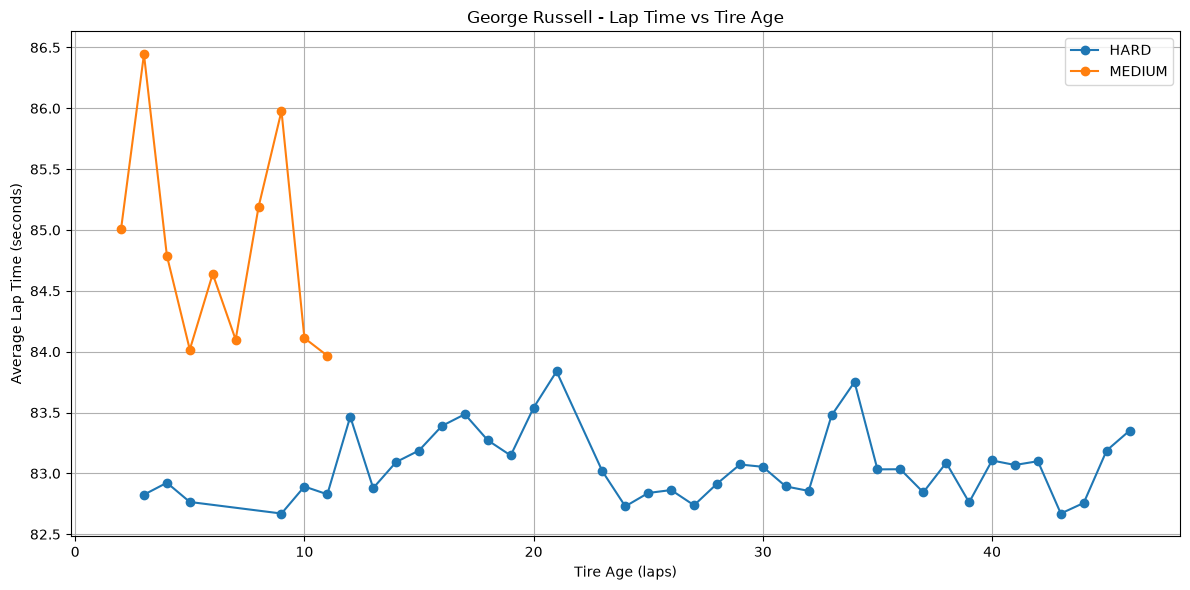

In [36]:
# ============================================================
# RUSSELL TIRE DEGRADATION GRAPH
# ============================================================

plt.figure(figsize=(12, 6))

for compound in rus_degradation["Compound"].dropna().unique():

    data = rus_degradation[
        rus_degradation["Compound"] == compound
    ]

    plt.plot(
        data["TyreLife"],
        data["AverageLapTime"],
        marker="o",
        label=compound
    )

plt.xlabel("Tire Age (laps)")
plt.ylabel("Average Lap Time (seconds)")

plt.title(
    "George Russell - Lap Time vs Tire Age"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/russell_tire_degradation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

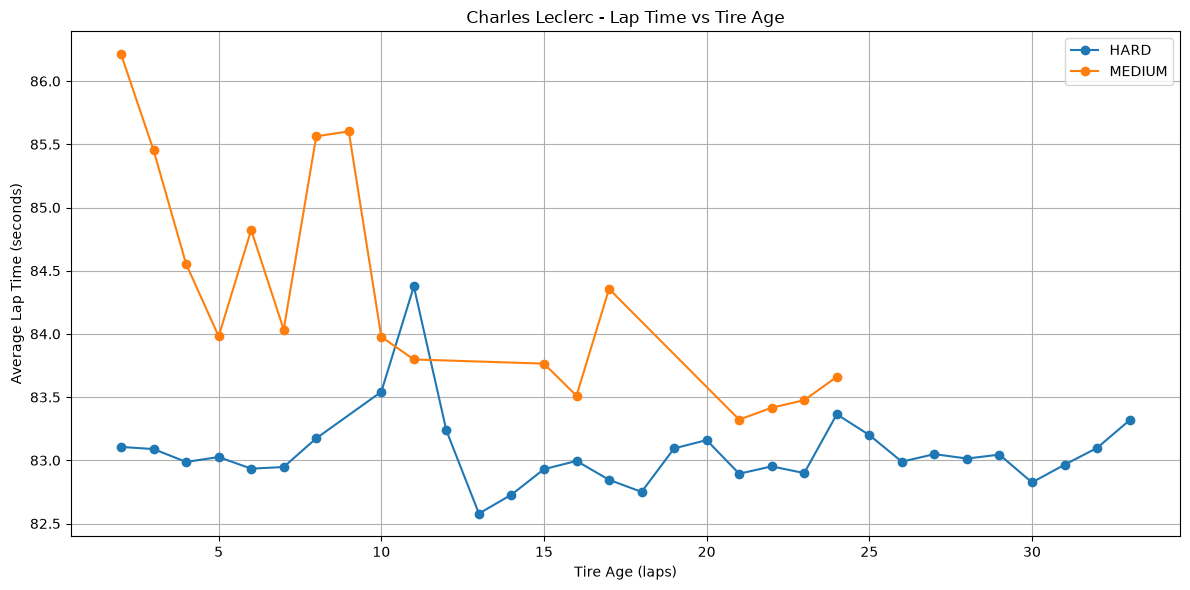

In [37]:
# ============================================================
# LECLERC TIRE DEGRADATION GRAPH
# ============================================================

plt.figure(figsize=(12, 6))

for compound in lec_degradation["Compound"].dropna().unique():

    data = lec_degradation[
        lec_degradation["Compound"] == compound
    ]

    plt.plot(
        data["TyreLife"],
        data["AverageLapTime"],
        marker="o",
        label=compound
    )

plt.xlabel("Tire Age (laps)")
plt.ylabel("Average Lap Time (seconds)")

plt.title(
    "Charles Leclerc - Lap Time vs Tire Age"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/leclerc_tire_degradation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# ============================================================
# RUSSELL DEGRADATION RATE
# ============================================================

print("========== GEORGE RUSSELL DEGRADATION RATES ==========")

for compound in rus_degradation["Compound"].dropna().unique():

    data = rus_degradation[
        rus_degradation["Compound"] == compound
    ].copy()

    data = data.dropna(
        subset=["TyreLife", "AverageLapTime"]
    )

    # Need at least 2 points to calculate a trend
    if len(data) >= 2:

        slope = np.polyfit(
            data["TyreLife"],
            data["AverageLapTime"],
            1
        )[0]

        print(
            f"{compound}: "
            f"{slope:.4f} seconds/lap"
        )

    else:

        print(
            f"{compound}: "
            "Not enough data"
        )

========== GEORGE RUSSELL DEGRADATION RATES ==========
HARD: 0.0007 seconds/lap
MEDIUM: -0.1016 seconds/lap


In [22]:
# ============================================================
# LECLERC DEGRADATION RATE
# ============================================================

print("========== CHARLES LECLERC DEGRADATION RATES ==========")

for compound in lec_degradation["Compound"].dropna().unique():

    data = lec_degradation[
        lec_degradation["Compound"] == compound
    ].copy()

    data = data.dropna(
        subset=["TyreLife", "AverageLapTime"]
    )

    if len(data) >= 2:

        slope = np.polyfit(
            data["TyreLife"],
            data["AverageLapTime"],
            1
        )[0]

        print(
            f"{compound}: "
            f"{slope:.4f} seconds/lap"
        )

    else:

        print(
            f"{compound}: "
            "Not enough data"
        )

========== CHARLES LECLERC DEGRADATION RATES ==========
HARD: -0.0028 seconds/lap
MEDIUM: -0.0883 seconds/lap


In [23]:
# ============================================================
# COMBINED DEGRADATION SUMMARY
# ============================================================

degradation_results = []

# Russell
for compound in rus_degradation["Compound"].dropna().unique():

    data = rus_degradation[
        rus_degradation["Compound"] == compound
    ].dropna(
        subset=["TyreLife", "AverageLapTime"]
    )

    if len(data) >= 2:

        slope = np.polyfit(
            data["TyreLife"],
            data["AverageLapTime"],
            1
        )[0]

        degradation_results.append({
            "Driver": "George Russell",
            "Compound": compound,
            "DegradationRate_sec_per_lap": slope
        })


# Leclerc
for compound in lec_degradation["Compound"].dropna().unique():

    data = lec_degradation[
        lec_degradation["Compound"] == compound
    ].dropna(
        subset=["TyreLife", "AverageLapTime"]
    )

    if len(data) >= 2:

        slope = np.polyfit(
            data["TyreLife"],
            data["AverageLapTime"],
            1
        )[0]

        degradation_results.append({
            "Driver": "Charles Leclerc",
            "Compound": compound,
            "DegradationRate_sec_per_lap": slope
        })


degradation_summary = pd.DataFrame(
    degradation_results
)

print("========== DEGRADATION SUMMARY ==========")

print(
    degradation_summary.round(4)
)

========== DEGRADATION SUMMARY ==========
            Driver Compound  DegradationRate_sec_per_lap
0   George Russell     HARD                       0.0007
1   George Russell   MEDIUM                      -0.1016
2  Charles Leclerc     HARD                      -0.0028
3  Charles Leclerc   MEDIUM                      -0.0883


In [24]:
# ============================================================
# COMBINED STINT STRATEGY
# ============================================================

rus_strategy = rus_stints.copy()
rus_strategy["Driver"] = "George Russell"

lec_strategy = lec_stints.copy()
lec_strategy["Driver"] = "Charles Leclerc"

strategy_summary = pd.concat(
    [
        rus_strategy,
        lec_strategy
    ],
    ignore_index=True
)

strategy_summary = strategy_summary[
    [
        "Driver",
        "Stint",
        "Compound",
        "StartLap",
        "EndLap",
        "Laps",
        "MaxTyreLife"
    ]
]

print("========== TIRE STRATEGY COMPARISON ==========")

print(strategy_summary)

========== TIRE STRATEGY COMPARISON ==========
            Driver  Stint Compound  StartLap  EndLap  Laps  MaxTyreLife
0   George Russell    1.0   MEDIUM       1.0    12.0    12         12.0
1   George Russell    2.0     HARD      13.0    58.0    46         46.0
2  Charles Leclerc    1.0   MEDIUM       1.0    25.0    25         25.0
3  Charles Leclerc    2.0     HARD      26.0    58.0    33         33.0


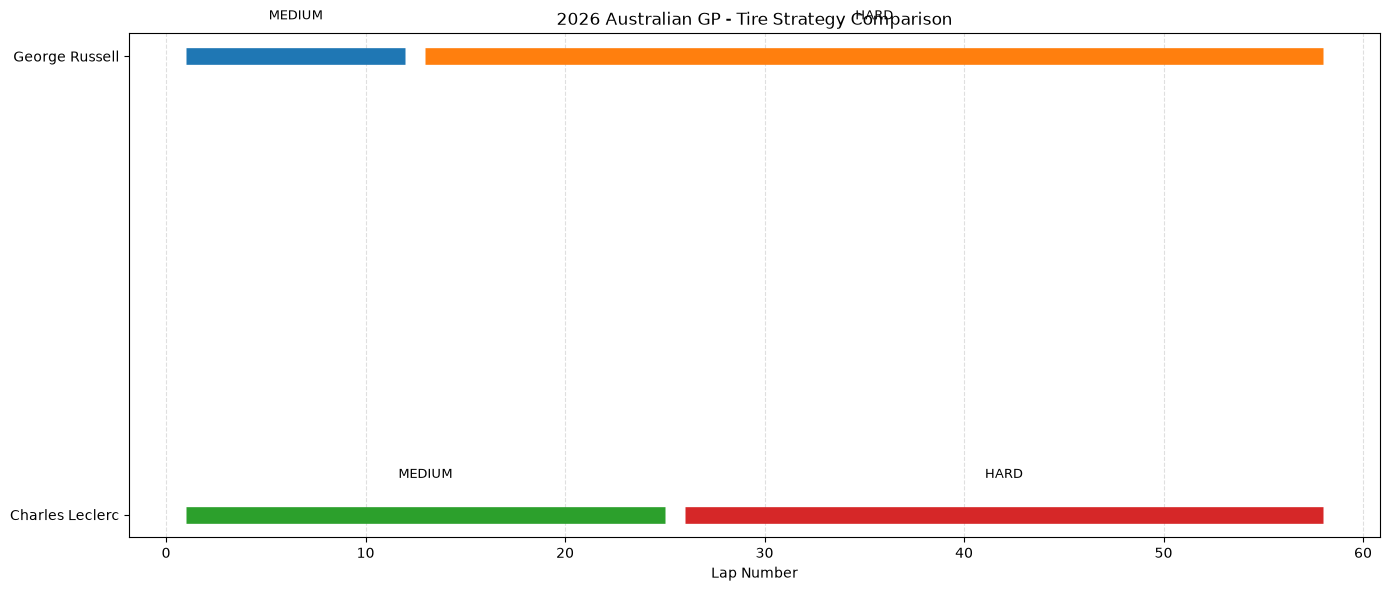

In [38]:
# ============================================================
# TIRE STRATEGY TIMELINE
# ============================================================

plt.figure(figsize=(14, 6))

drivers = [
    ("George Russell", rus_stints),
    ("Charles Leclerc", lec_stints)
]

y_positions = [1, 0]

for (driver_name, stints), y in zip(
    drivers,
    y_positions
):

    for _, stint in stints.iterrows():

        start = stint["StartLap"]
        end = stint["EndLap"]

        compound = str(
            stint["Compound"]
        )

        plt.plot(
            [start, end],
            [y, y],
            linewidth=12,
            solid_capstyle="butt"
        )

        plt.text(
            (start + end) / 2,
            y + 0.08,
            compound,
            ha="center",
            fontsize=9
        )

plt.yticks(
    [0, 1],
    ["Charles Leclerc", "George Russell"]
)

plt.xlabel("Lap Number")

plt.title(
    "2026 Australian GP - Tire Strategy Comparison"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/tire_strategy_timeline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
# ============================================================
# LONGEST TIRE STINT
# ============================================================

longest_stints = strategy_summary.loc[
    strategy_summary.groupby("Driver")["Laps"].idxmax()
]

print("========== LONGEST TIRE STINT ==========")

print(longest_stints)

========== LONGEST TIRE STINT ==========
            Driver  Stint Compound  StartLap  EndLap  Laps  MaxTyreLife
3  Charles Leclerc    2.0     HARD      26.0    58.0    33         33.0
1   George Russell    2.0     HARD      13.0    58.0    46         46.0


In [27]:
# ============================================================
# AVERAGE LAP TIME BY COMPOUND
# ============================================================

rus_compound_pace = (
    rus_clean
    .groupby("Compound", dropna=False)
    ["LapTimeSeconds"]
    .agg(
        AverageLapTime="mean",
        BestLapTime="min",
        LapCount="count"
    )
    .reset_index()
)

lec_compound_pace = (
    lec_clean
    .groupby("Compound", dropna=False)
    ["LapTimeSeconds"]
    .agg(
        AverageLapTime="mean",
        BestLapTime="min",
        LapCount="count"
    )
    .reset_index()
)

print("========== RUSSELL COMPOUND PACE ==========")
print(rus_compound_pace.round(3))

print("\n========== LECLERC COMPOUND PACE ==========")
print(lec_compound_pace.round(3))

========== RUSSELL COMPOUND PACE ==========
  Compound  AverageLapTime  BestLapTime  LapCount
0     HARD          83.060       82.670        40
1   MEDIUM          84.824       83.967        10

========== LECLERC COMPOUND PACE ==========
  Compound  AverageLapTime  BestLapTime  LapCount
0     HARD          83.068       82.579        31
1   MEDIUM          84.324       83.322        17


In [28]:
# ============================================================
# TIRE DEGRADATION REGRESSION
# ============================================================

def calculate_degradation(data, driver_name):

    results = []

    for compound in data["Compound"].dropna().unique():

        subset = data[
            data["Compound"] == compound
        ].dropna(
            subset=[
                "TyreLife",
                "AverageLapTime"
            ]
        )

        if len(subset) < 2:
            continue

        x = subset["TyreLife"].values
        y = subset["AverageLapTime"].values

        slope, intercept = np.polyfit(
            x,
            y,
            1
        )

        correlation = np.corrcoef(
            x,
            y
        )[0, 1]

        results.append({
            "Driver": driver_name,
            "Compound": compound,
            "Degradation_sec_per_lap": slope,
            "Correlation": correlation,
            "DataPoints": len(subset)
        })

    return pd.DataFrame(results)


rus_degradation_regression = calculate_degradation(
    rus_degradation,
    "George Russell"
)

lec_degradation_regression = calculate_degradation(
    lec_degradation,
    "Charles Leclerc"
)

final_degradation = pd.concat(
    [
        rus_degradation_regression,
        lec_degradation_regression
    ],
    ignore_index=True
)

print("========== TIRE DEGRADATION REGRESSION ==========")

print(
    final_degradation.round(4)
)

========== TIRE DEGRADATION REGRESSION ==========
            Driver Compound  Degradation_sec_per_lap  Correlation  DataPoints
0   George Russell     HARD                   0.0007       0.0283          40
1   George Russell   MEDIUM                  -0.1016      -0.3597          10
2  Charles Leclerc     HARD                  -0.0028      -0.0841          31
3  Charles Leclerc   MEDIUM                  -0.0883      -0.7301          17


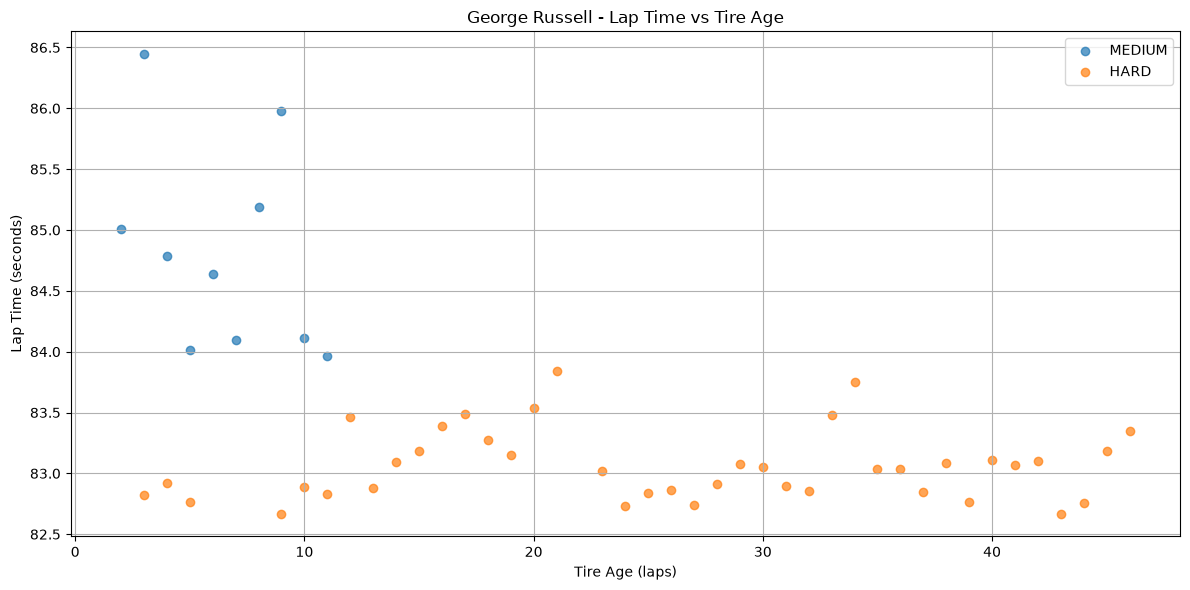

In [29]:
# ============================================================
# RUSSELL: LAP TIME VS TIRE AGE
# ============================================================

plt.figure(figsize=(12, 6))

for compound in rus_clean["Compound"].dropna().unique():

    data = rus_clean[
        rus_clean["Compound"] == compound
    ]

    plt.scatter(
        data["TyreLife"],
        data["LapTimeSeconds"],
        label=compound,
        alpha=0.7
    )

plt.xlabel("Tire Age (laps)")
plt.ylabel("Lap Time (seconds)")

plt.title(
    "George Russell - Lap Time vs Tire Age"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

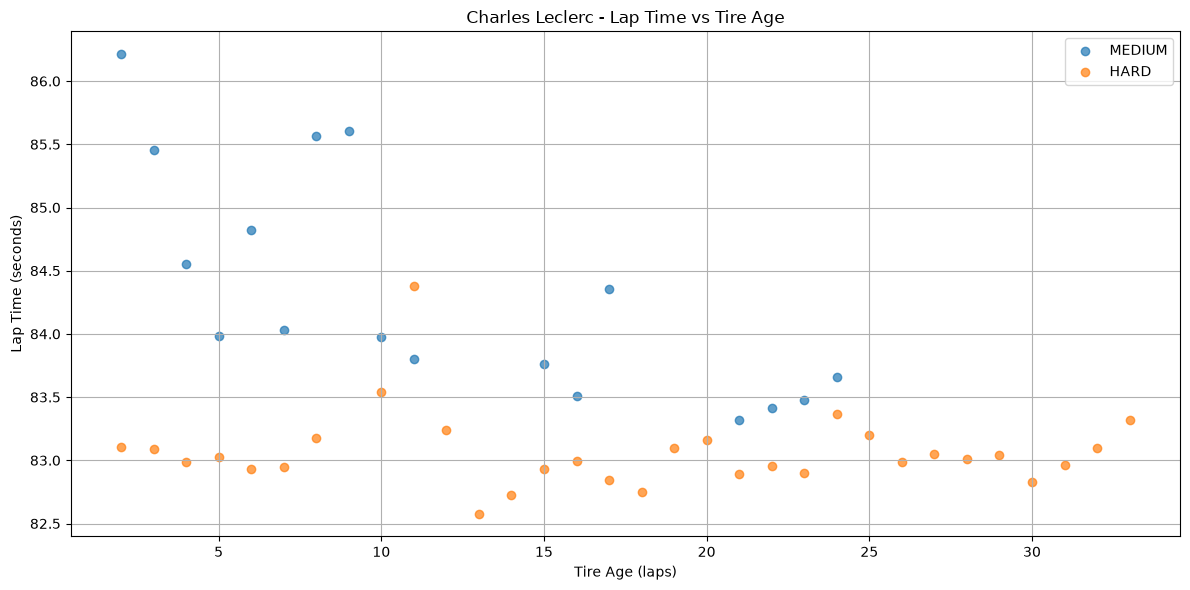

In [30]:
# ============================================================
# LECLERC: LAP TIME VS TIRE AGE
# ============================================================

plt.figure(figsize=(12, 6))

for compound in lec_clean["Compound"].dropna().unique():

    data = lec_clean[
        lec_clean["Compound"] == compound
    ]

    plt.scatter(
        data["TyreLife"],
        data["LapTimeSeconds"],
        label=compound,
        alpha=0.7
    )

plt.xlabel("Tire Age (laps)")
plt.ylabel("Lap Time (seconds)")

plt.title(
    "Charles Leclerc - Lap Time vs Tire Age"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

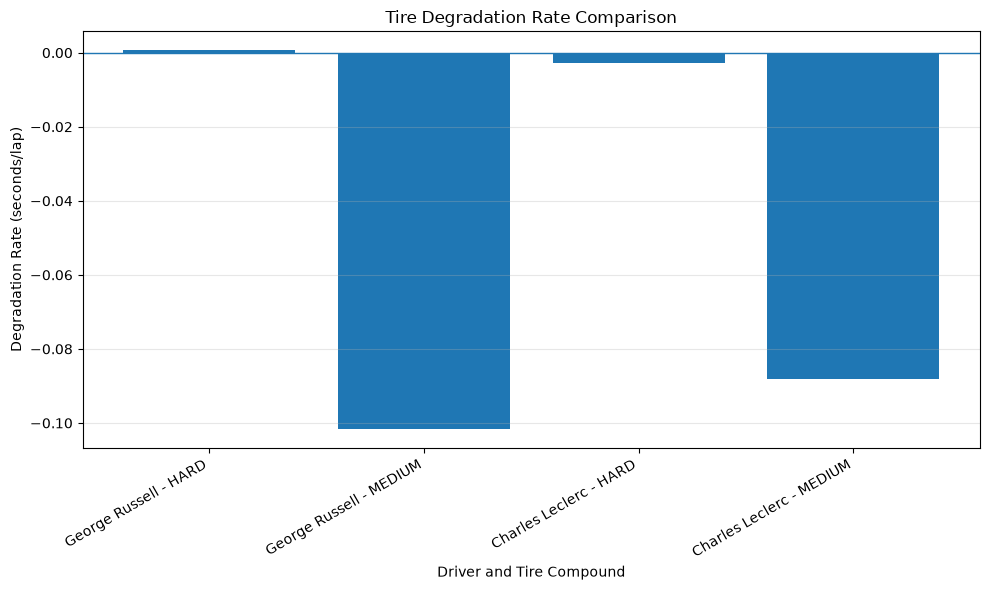

In [31]:
# ============================================================
# DEGRADATION RATE COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

labels = (
    final_degradation["Driver"]
    + " - "
    + final_degradation["Compound"]
)

values = final_degradation[
    "Degradation_sec_per_lap"
]

plt.bar(
    labels,
    values
)

plt.axhline(
    0,
    linewidth=1
)

plt.ylabel(
    "Degradation Rate (seconds/lap)"
)

plt.xlabel(
    "Driver and Tire Compound"
)

plt.title(
    "Tire Degradation Rate Comparison"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [32]:
# ============================================================
# FINAL STRATEGY SUMMARY
# ============================================================

final_strategy = strategy_summary[
    [
        "Driver",
        "Stint",
        "Compound",
        "StartLap",
        "EndLap",
        "Laps",
        "MaxTyreLife"
    ]
].copy()

print("========== FINAL STRATEGY SUMMARY ==========")

print(
    final_strategy.to_string(index=False)
)

========== FINAL STRATEGY SUMMARY ==========
         Driver  Stint Compound  StartLap  EndLap  Laps  MaxTyreLife
 George Russell    1.0   MEDIUM       1.0    12.0    12         12.0
 George Russell    2.0     HARD      13.0    58.0    46         46.0
Charles Leclerc    1.0   MEDIUM       1.0    25.0    25         25.0
Charles Leclerc    2.0     HARD      26.0    58.0    33         33.0


In [34]:
# ============================================================
# TOTAL LAPS BY COMPOUND
# ============================================================

rus_compound_laps = (
    rus_clean
    .groupby("Compound")
    .size()
    .reset_index(
        name="Laps"
    )
)

lec_compound_laps = (
    lec_clean
    .groupby("Compound")
    .size()
    .reset_index(
        name="Laps"
    ))

print("========== RUSSELL COMPOUND USAGE ==========")
print(rus_compound_laps)

print("\n========== LECLERC COMPOUND USAGE ==========")
print(lec_compound_laps)

========== RUSSELL COMPOUND USAGE ==========
  Compound  Laps
0     HARD    40
1   MEDIUM    10

========== LECLERC COMPOUND USAGE ==========
  Compound  Laps
0     HARD    31
1   MEDIUM    17


In [35]:
# ============================================================
# FINAL DRIVER COMPARISON STATISTICS
# ============================================================

print("\n==============================================")
print("        FINAL DRIVER COMPARISON")
print("==============================================")

print(
    f"\nRussell average speed: "
    f"{256.19:.2f} km/h"
)

print(
    f"Leclerc average speed: "
    f"{252.42:.2f} km/h"
)

print(
    f"Russell speed advantage: "
    f"{3.76:.2f} km/h"
)

print(
    "\nRussell faster at "
    "78.40% of comparison points"
)

print(
    "Leclerc faster at "
    "21.20% of comparison points"
)

print(
    "\nRussell longest Hard stint: "
    "46 laps"
)

print(
    "Leclerc longest Hard stint: "
    "33 laps"
)

print(
    "\nRussell Hard average lap: "
    "83.060 s"
)

print(
    "Leclerc Hard average lap: "
    "83.068 s"
)

print(
    "\nRussell Medium average lap: "
    "84.824 s"
)

print(
    "Leclerc Medium average lap: "
    "84.324 s"
)


        FINAL DRIVER COMPARISON

Russell average speed: 256.19 km/h
Leclerc average speed: 252.42 km/h
Russell speed advantage: 3.76 km/h

Russell faster at 78.40% of comparison points
Leclerc faster at 21.20% of comparison points

Russell longest Hard stint: 46 laps
Leclerc longest Hard stint: 33 laps

Russell Hard average lap: 83.060 s
Leclerc Hard average lap: 83.068 s

Russell Medium average lap: 84.824 s
Leclerc Medium average lap: 84.324 s
